In [1]:
import pandas as pd
import os
import shutil
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
dfddi=pd.read_csv(r"C:\Users\akhil\Documents\Dissertation work\data\ddi_dataset\ddidiversedermatologyimages\ddi_metadata.csv")
print(dfddi.head())
print(dfddi,dfddi.shape)

   Unnamed: 0  DDI_ID    DDI_file  skin_tone  malignant  \
0           0       1  000001.png         56       True   
1           1       2  000002.png         56       True   
2           2       3  000003.png         56       True   
3           3       4  000004.png         56       True   
4           4       5  000005.png         12       True   

                           disease  
0                 melanoma-in-situ  
1                 melanoma-in-situ  
2                mycosis-fungoides  
3  squamous-cell-carcinoma-in-situ  
4             basal-cell-carcinoma  
     Unnamed: 0  DDI_ID    DDI_file  skin_tone  malignant  \
0             0       1  000001.png         56       True   
1             1       2  000002.png         56       True   
2             2       3  000003.png         56       True   
3             3       4  000004.png         56       True   
4             4       5  000005.png         12       True   
..          ...     ...         ...        ...        ...

In [5]:
diseases = dfddi['malignant'].unique()
print(diseases)
perdisease_counts = dfddi['malignant'].value_counts()
print(perdisease_counts)

[ True False]
malignant
False    485
True     171
Name: count, dtype: int64


In [7]:
dfddi = dfddi[['DDI_file', 'malignant', 'skin_tone']]

In [8]:
print(dfddi['skin_tone'].unique())

[56 12 34]


In [9]:
singlecount = pd.crosstab(dfddi['malignant'], dfddi['skin_tone'])
print(singlecount)

skin_tone   12   34   56
malignant               
False      159  167  159
True        49   74   48


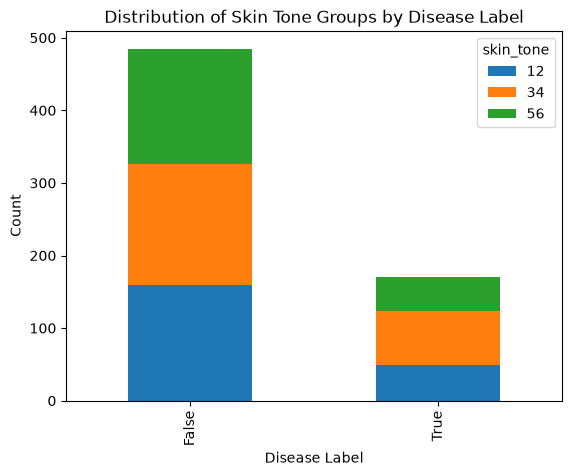

In [10]:
import matplotlib.pyplot as plt
bar = singlecount.plot.bar(stacked=True)
plt.title('Distribution of Skin Tone Groups by Disease Label')
plt.xlabel('Disease Label')
plt.ylabel('Count')
plt.show()

In [12]:

from sklearn.model_selection import train_test_split


traindata, t = train_test_split(dfddi, test_size=0.30, random_state=42,
                                stratify=dfddi[['malignant', 'skin_tone']])
valdata, testdata = train_test_split(t, test_size=0.50, random_state=42,
                                     stratify=t[['malignant', 'skin_tone']])

traindata.to_csv("data/dditrain.csv", index=False)
valdata.to_csv("data/ddival.csv", index=False)
testdata.to_csv("data/dditest.csv", index=False)

In [14]:
traindf = pd.read_csv("data/dditrain.csv")
print(traindf.shape)
print(traindf['skin_tone'].value_counts())

(459, 3)
skin_tone
34    169
12    145
56    145
Name: count, dtype: int64


In [18]:
import os
import shutil
imagepath = r"C:\Users\akhil\Documents\Dissertation work\data\ddi_dataset\ddidiversedermatologyimages"
splitpath = "data/ddisplitimages"
trainpath = os.path.join(splitpath, "train")
valpath   = os.path.join(splitpath, "val")
testpath  = os.path.join(splitpath, "test")


for a, b in traindata.iterrows():
    traindest = os.path.join(trainpath, str(b['malignant']), b['DDI_file'])
    source = os.path.join(imagepath, b['DDI_file'])
    os.makedirs(os.path.dirname(traindest), exist_ok=True)
    shutil.copy(source, traindest)

for a, b in valdata.iterrows():
    valdest = os.path.join(valpath, str(b['malignant']), b['DDI_file'])
    source = os.path.join(imagepath, b['DDI_file'])
    os.makedirs(os.path.dirname(valdest), exist_ok=True)
    shutil.copy(source, valdest)
 
for a, b in testdata.iterrows():
    testdest = os.path.join(testpath, str(b['malignant']), b['DDI_file'])
    source = os.path.join(imagepath, b['DDI_file'])
    os.makedirs(os.path.dirname(testdest), exist_ok=True)
    shutil.copy(source, testdest)

fitzt12 = testdata[testdata['skin_tone'] == 12]
fitzt34 = testdata[testdata['skin_tone'] == 34]
fitzt56 = testdata[testdata['skin_tone'] == 56]
 
fitzt12path = "data/ddi_splitimages/skin12"
fitzt34path = "data/ddi_splitimages/skin34"
fitzt56path = "data/ddi_splitimages/skin56"

for a, b in fitzt12.iterrows():
    dest = os.path.join(fitzt12path, str(b['malignant']), b['DDI_file'])
    source = os.path.join(imagepath, b['DDI_file'])
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    shutil.copy(source, dest)
 
for a, b in fitzt34.iterrows():
    dest = os.path.join(fitzt34path, str(b['malignant']), b['DDI_file'])
    source = os.path.join(imagepath, b['DDI_file'])
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    shutil.copy(source, dest)
 
for a, b in fitzt56.iterrows():
    dest = os.path.join(fitzt56path, str(b['malignant']), b['DDI_file'])
    source = os.path.join(imagepath, b['DDI_file'])
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    shutil.copy(source, dest)

In [ ]:
import numpy as np
from PIL import Image
meanone, meantwo, meanthree = 0, 0, 0
stdone, stdtwo, stdthree = 0, 0, 0
num = 0
 
for a, b in traindata.iterrows():
    source = os.path.join(imagepath, b['DDI_file'])
    arr = np.array(Image.open(source).convert('RGB'))
    meanone += arr[:, :, 0].mean()
    meantwo += arr[:, :, 1].mean()
    meanthree += arr[:, :, 2].mean()
    stdone += arr[:, :, 0].std()
    stdtwo += arr[:, :, 1].std()
    stdthree += arr[:, :, 2].std()
    num += 1


meanone = (meanone / num) / 255
meantwo = (meantwo / num) / 255
meanthree = (meanthree / num) / 255
stdone = (stdone / num) / 255
stdtwo = (stdtwo / num) / 255
stdthree = (stdthree / num) / 255
 
print("Means:", meanone, meantwo, meanthree)
print("Stds:", stdone, stdtwo, stdthree)

Means: 0.5973136068634974 0.48354200528979285 0.4030073064453022
Stds: 0.16094550631078788 0.1692119350093838 0.17503342464452973


In [ ]:
transformsone = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[meanone, meantwo, meanthree], std=[stdone, stdtwo, stdthree])
])

transformstwo = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[meanone, meantwo, meanthree], std=[stdone, stdtwo, stdthree])
])

In [ ]:
import torch
from torch.utils.data import DataLoader

traindataset  = datasets.ImageFolder(root=r"data\ddisplitimages\train", transform=transformsone)
valdataset    = datasets.ImageFolder(root=r"data\ddisplitimages\val",   transform=transformstwo)
testdataset   = datasets.ImageFolder(root=r"data\ddisplitimages\test",  transform=transformstwo)

fitzt12dataset = datasets.ImageFolder(root=r"data\ddi_splitimages\skin12", transform=transformstwo)
fitzt34dataset = datasets.ImageFolder(root=r"data\ddi_splitimages\skin34", transform=transformstwo)
fitzt56dataset = datasets.ImageFolder(root=r"data\ddi_splitimages\skin56", transform=transformstwo)

trainn     = DataLoader(traindataset,  shuffle=True,  batch_size=32, num_workers=0, pin_memory=True)
vall       = DataLoader(valdataset,    shuffle=False, batch_size=32, num_workers=0, pin_memory=True)
testt      = DataLoader(testdataset,   shuffle=False, batch_size=32, num_workers=0, pin_memory=True)
fitz12data = DataLoader(fitzt12dataset, shuffle=False, batch_size=32, num_workers=0, pin_memory=True)
fitz34data = DataLoader(fitzt34dataset, shuffle=False, batch_size=32, num_workers=0, pin_memory=True)
fitz56data = DataLoader(fitzt56dataset, shuffle=False, batch_size=32, num_workers=0, pin_memory=True)

In [27]:
if torch.cuda.is_available():
    computation = "cuda"
else:
    computation = "cpu"
device = torch.device(computation)

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

class FocalLoss(nn.Module):
    def __init__(self, g=0, a=None, size_average=True):
        super(FocalLoss, self).__init__()
        self.gamma = g
        self.alpha = a
        if isinstance(a, (float, int)):
            self.alpha = torch.Tensor([a, 1 - a])
        if isinstance(a, list):
            self.alpha = torch.Tensor(a)
        self.size_average = size_average
 
    def forward(self, input, target):
        if input.dim() > 2:
            input = input.view(input.size(0), input.size(1), -1)
            input = input.transpose(1, 2)
            input = input.contiguous().view(-1, input.size(2))
        target = target.view(-1, 1)
        logpt = F.log_softmax(input, dim=1)
        logpt = logpt.gather(1, target)
        logpt = logpt.view(-1)
        pt = logpt.exp()
        if self.alpha is not None:
            if self.alpha.type() != input.data.type():
                self.alpha = self.alpha.type_as(input.data)
            at = self.alpha.gather(0, target.data.view(-1))
            logpt = logpt * at
        loss = -1 * (1 - pt) ** self.gamma * logpt
        if self.size_average:
            return loss.mean()
        else:
            return loss.sum()

In [ ]:
criterion= nn.CrossEntropyLoss()
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, roc_auc_score, balanced_accuracy_score
 
def evaluateskin(model, dataloader, device):
    corr = []
    predictions = []
    probabilities = []
    model.eval()
    ls = 0
    accur, total = 0, 0
    with torch.inference_mode():
        for batches, (x, y) in enumerate(dataloader):
            x = x.to(device)
            y = y.to(device)
            forward = model(x)
            probabilities = torch.nn.functional.softmax(forward, dim=1)
            loss = criterion(forward, y)
            ls += loss.item()
            forwardclass = forward.argmax(dim=1)
            
            corr.extend(y.cpu().numpy())
            probabilities.extend(probabilities.cpu().numpy())
            predictions.extend(forwardclass.cpu().numpy())
            accur =accur + (forwardclass == y).sum().item()
            total =total + len(y)
    avgacc = accur / total
    avgloss = ls / len(dataloader)
    precision, recall, f1, f2 = precision_recall_fscore_support(corr, predictions, average=None)
    auc = roc_auc_score(np.array(corr), np.array(probabilities)[:, 1])    
    fnr = 1 - recall
    balancedacc = balanced_accuracy_score(corr, predictions)
    confusionmatrix = confusion_matrix(corr, predictions)
    print(f"The  accuracy for the dataset is : {avgacc}")
    print(f"The precision for the dataset is {precision}")
    print(f"The AUC score for the dataset is {auc}")
    print(f"The recall for the dataset is  {recall}")
    print(f"The Loss: for the dataaset is {avgloss}")
    print(f"The False Negative Rate for the dataset is {fnr}")
    print(f"The confusion matrix for the dataset is:{confusionmatrix}")
    print(f"The balanced accuracy for the dataset is: {balancedacc}")
 

In [ ]:
import torchvision.models as models
import torch.optim as optim
 
rate = 0.001
nepochs = 50
classes = 2
lam = 0.01
pat = 5


In [ ]:
resnet = models.resnet50(pretrained=True)
resnet.fc = torch.nn.Linear(resnet.fc.in_features, classes)
resnet = resnet.to(device)

c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [139]:
optimizer = optim.Adam(resnet.parameters(), lr=rate)


In [ ]:
lossvalues = []
lossvalues2 = []
limepoch = 0
maxvalloss = 1000

for epoch in range(nepochs):
    resnet.train()
    total, l, totalaccur = 0, 0, 0
    for batches, (a, b) in enumerate(trainn):
        a = a.to(device)
        b = b.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            forward = resnet(a)
            lossc = F.cross_entropy(forward, b)
            sdloss = 0.5 * torch.mean(forward ** 2)
            loss = lossc + lam * sdloss
        loss.backward()
        optimizer.step()
        l += loss.item()
        forwardclass = forward.argmax(dim=1)
        totalaccur += (forwardclass == b).sum().item()
    avgacc = totalaccur / len(traindataset) * 100
    avgloss = l / len(trainn)
    lossvalues.append(avgloss)
    print(f"Epoch number {epoch + 1}")
    print("-----")
    print(f"The training acc is: {avgacc}")
    print("-----")
    print(f"The training loss is: {avgloss}")

    resnet.eval()
    l2, accur2 = 0, 0
    with torch.no_grad():
        for batches, (a1, b1) in enumerate(vall):
            a1 = a1.to(device)
            b1 = b1.to(device)
            forward1 = resnet(a1)
            vallossc = F.cross_entropy(forward1, b1)
            sdvalloss = 0.5 * torch.mean(forward1 ** 2)
            loss2 = vallossc + lam * sdvalloss
            l2 += loss2.item()
            forwardclass1 = forward1.argmax(dim=1)
            accur2 =accur2+ (forwardclass1 == b1).sum().item() / len(forward1)
        avgvalacc = accur2 / len(vall) * 100
        avgvalloss = l2 / len(vall)
        lossvalues2.append(avgvalloss)
        print(f"The validation acc is: {avgvalacc}")
        print(f"The validation loss is: {avgvalloss}")

    if avgvalloss < maxvalloss:
        maxvalloss = avgvalloss
        limepoch = 0
        torch.save(resnet.state_dict(), r"c:\Users\akhil\Downloads\ddi_resnetspectral.pth")
    else:
        limepoch += 1
        print("val loss stagnant")
        if limepoch >= pat:
            print(f"final stop at epoch {epoch + 1}")
            break

    


Epoch number 1
//////
The training acc is: 71.67755991285402
/////
The training loss is: 0.7263141711552937
The validation acc is: 57.8125
The validation loss is: 340.37535858154297
Epoch number 2
//////
The training acc is: 75.16339869281046
/////
The training loss is: 0.5633434275786082
The validation acc is: 67.96875
The validation loss is: 0.5512123554944992
Epoch number 3
//////
The training acc is: 73.8562091503268
/////
The training loss is: 0.571533598502477
The validation acc is: 57.03125
The validation loss is: 0.6830881685018539
No improvement: 1/3
Epoch number 4
//////
The training acc is: 73.8562091503268
/////
The training loss is: 0.5593626916408538
The validation acc is: 72.65625
The validation loss is: 0.6140439957380295
No improvement: 2/3
Epoch number 5
//////
The training acc is: 75.16339869281046
/////
The training loss is: 0.5563160439332326
The validation acc is: 71.875
The validation loss is: 0.664471473544836
No improvement: 3/3
Epoch number 6
//////
The traini

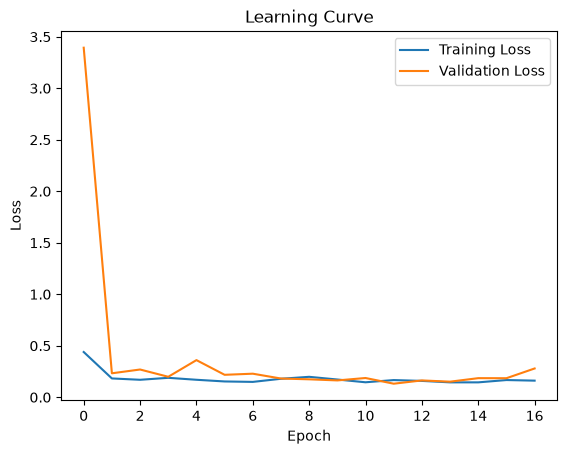

In [ ]:
##learning curve

import matplotlib.pyplot as plt

plt.plot(lossvalues, label="Training Loss")
plt.plot(lossvalues2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [143]:
print("Resnet evaluation on test data")
evaluateskin(resnet, testt, device)

Resnet evaluation on test data
The  accuracy for the dataset is : 0.7474747474747475
The precision for the dataset is [0.81578947 0.52173913]
The AUC score for the dataset is 0.7592202318229716
The recall for the dataset is  [0.84931507 0.46153846]
The Loss: for the dataaset is 0.38548098504543304
The False Negative Rate for the dataset is [0.15068493 0.53846154]
The confusion matrix for the dataset is:[[62 11]
 [14 12]]
The balanced accuracy for the dataset is: 0.6554267650158061


In [144]:
print("Resnet evaluation fitzpatrick 1 and 2 ")
evaluateskin(resnet, fitz12data, device)

Resnet evaluation fitzpatrick 1 and 2 
The  accuracy for the dataset is : 0.875
The precision for the dataset is [0.88461538 0.83333333]
The AUC score for the dataset is 0.890625
The recall for the dataset is  [0.95833333 0.625     ]
The Loss: for the dataaset is 0.13764846324920654
The False Negative Rate for the dataset is [0.04166667 0.375     ]
The confusion matrix for the dataset is:[[23  1]
 [ 3  5]]
The balanced accuracy for the dataset is: 0.7916666666666667


In [145]:
print("Resnet evaluation fitzpatrick 3 and 4")
evaluateskin(resnet, fitz34data, device)

Resnet evaluation fitzpatrick 3 and 4
The  accuracy for the dataset is : 0.7222222222222222
The precision for the dataset is [0.8        0.54545455]
The AUC score for the dataset is 0.7745454545454545
The recall for the dataset is  [0.8        0.54545455]
The Loss: for the dataaset is 0.47718068957328796
The False Negative Rate for the dataset is [0.2        0.45454545]
The confusion matrix for the dataset is:[[20  5]
 [ 5  6]]
The balanced accuracy for the dataset is: 0.6727272727272727


In [146]:
print("Resnet evaluation on fitzpatrick 5 and 6")
evaluateskin(resnet, fitz56data, device)

Resnet evaluation on fitzpatrick 5 and 6
The  accuracy for the dataset is : 0.6451612903225806
The precision for the dataset is [0.76       0.16666667]
The AUC score for the dataset is 0.6428571428571428
The recall for the dataset is  [0.79166667 0.14285714]
The Loss: for the dataaset is 0.48160505294799805
The False Negative Rate for the dataset is [0.20833333 0.85714286]
The confusion matrix for the dataset is:[[19  5]
 [ 6  1]]
The balanced accuracy for the dataset is: 0.46726190476190477


In [ ]:
densenet = models.densenet121(pretrained=True)
densenet.classifier = torch.nn.Linear(densenet.classifier.in_features, classes)
densenet = densenet.to(device)
optimizer = optim.Adam(densenet.parameters(), lr=rate)

In [ ]:
lossvalues = []
lossvalues2 = []
limepoch = 0
maxvalloss = 1000

for epoch in range(nepochs):
    densenet.train()
    total, l, totalaccur = 0, 0, 0
    for batches, (a, b) in enumerate(trainn):
        a = a.to(device)
        b = b.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            forward = densenet(a)
            lossc = F.cross_entropy(forward, b)
            sdloss = 0.5 * torch.mean(forward ** 2)
            loss = lossc + lam * sdloss
        loss.backward()
        optimizer.step()
        l += loss.item()
        forwardclass = forward.argmax(dim=1)
        totalaccur += (forwardclass == b).sum().item()
    avgacc = totalaccur / len(traindataset) * 100
    avgloss = l / len(trainn)
    lossvalues.append(avgloss)
    print(f"Epoch number {epoch + 1}")
    print("-----")
    print(f"The training acc is: {avgacc}")
    print("-----")
    print(f"The training loss is: {avgloss}")

    densenet.eval()
    l2, accur2 = 0, 0
    with torch.no_grad():
        for batches, (a1, b1) in enumerate(vall):
            a1 = a1.to(device)
            b1 = b1.to(device)
            forward1 = densenet(a1)
            vallossc = F.cross_entropy(forward1, b1)
            sdvalloss = 0.5 * torch.mean(forward1 ** 2)
            loss2 = vallossc + lam * sdvalloss
            l2 += loss2.item()
            forwardclass1 = forward1.argmax(dim=1)
            accur2 =accur2+ (forwardclass1 == b1).sum().item() / len(forward1)
        avgvalacc = accur2 / len(vall) * 100
        avgvalloss = l2 / len(vall)
        lossvalues2.append(avgvalloss)
        print(f"The validation acc is: {avgvalacc}")
        print(f"The validation loss is: {avgvalloss}")

    if (avgvalloss < maxvalloss):
        maxvalloss = avgvalloss
        limepoch = 0
        torch.save(densenet.state_dict(), r"c:\Users\akhil\Downloads\ddidensenetspectral.pth")
    else:
        limepoch =limepoch+ 1   
        print("val loss stagnant")
        if (limepoch >= pat):
            print(f"final stop at epoch {epoch + 1}")
            break

Epoch number 1
//////
The training acc is: 71.24183006535948
/////
The training loss is: 0.6504449367523193
The validation acc is: 57.03125
The validation loss is: 1.692891038954258
Epoch number 2
//////
The training acc is: 72.98474945533769
/////
The training loss is: 0.5683802664279938
The validation acc is: 66.40625
The validation loss is: 0.6923120766878128
Epoch number 3
//////
The training acc is: 75.38126361655773
/////
The training loss is: 0.5357450723648072
The validation acc is: 57.03125
The validation loss is: 0.7155047357082367
No improvement: 1/5
Epoch number 4
//////
The training acc is: 75.16339869281046
/////
The training loss is: 0.5506902515888215
The validation acc is: 71.875
The validation loss is: 0.6376570761203766
Epoch number 5
//////
The training acc is: 75.81699346405229
/////
The training loss is: 0.515484211842219
The validation acc is: 57.8125
The validation loss is: 0.9243837893009186
No improvement: 1/5
Epoch number 6
//////
The training acc is: 76.9063

In [ ]:
##learning curve

import matplotlib.pyplot as plt

plt.plot(lossvalues, label="Training Loss")
plt.plot(lossvalues2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [154]:
print("densenet evaluation on test data")
evaluateskin(densenet, testt, device)

densenet evaluation on test data
The  accuracy for the dataset is : 0.7676767676767676
The precision for the dataset is [0.8125     0.57894737]
The AUC score for the dataset is 0.7507903055848263
The recall for the dataset is  [0.89041096 0.42307692]
The Loss: for the dataaset is 0.5633307686075568
The False Negative Rate for the dataset is [0.10958904 0.57692308]
The confusion matrix for the dataset is:[[65  8]
 [15 11]]
The balanced accuracy for the dataset is: 0.6567439409905164


In [153]:
print("densenet evaluation fitzpatrick 1 and 2 ")
evaluateskin(densenet, fitz12data, device)

densenet evaluation fitzpatrick 1 and 2 
The  accuracy for the dataset is : 0.78125
The precision for the dataset is [0.79310345 0.66666667]
The AUC score for the dataset is 0.8020833333333333
The recall for the dataset is  [0.95833333 0.25      ]
The Loss: for the dataaset is 0.3097902536392212
The False Negative Rate for the dataset is [0.04166667 0.75      ]
The confusion matrix for the dataset is:[[23  1]
 [ 6  2]]
The balanced accuracy for the dataset is: 0.6041666666666667


In [155]:
print("densenet evaluation fitzpatrick 3 and 4")
evaluateskin(densenet, fitz34data, device)

densenet evaluation fitzpatrick 3 and 4
The  accuracy for the dataset is : 0.7777777777777778
The precision for the dataset is [0.84       0.63636364]
The AUC score for the dataset is 0.8327272727272728
The recall for the dataset is  [0.84       0.63636364]
The Loss: for the dataaset is 0.6186441481113434
The False Negative Rate for the dataset is [0.16       0.36363636]
The confusion matrix for the dataset is:[[21  4]
 [ 4  7]]
The balanced accuracy for the dataset is: 0.7381818181818182


In [156]:
print("densenet evaluation fitzpatrick 5 and 6")
evaluateskin(densenet, fitz56data, device)

densenet evaluation fitzpatrick 5 and 6
The  accuracy for the dataset is : 0.7419354838709677
The precision for the dataset is [0.80769231 0.4       ]
The AUC score for the dataset is 0.5178571428571429
The recall for the dataset is  [0.875      0.28571429]
The Loss: for the dataaset is 0.5855205655097961
The False Negative Rate for the dataset is [0.125      0.71428571]
The confusion matrix for the dataset is:[[21  3]
 [ 5  2]]
The balanced accuracy for the dataset is: 0.5803571428571428


In [ ]:
vit = models.vit_b_16(pretrained=True)
vit.heads.head = torch.nn.Linear(vit.heads.head.in_features, classes)
vit = vit.to(device)
optimizer = optim.Adam(vit.parameters(), lr=rate)
scaler = torch.amp.GradScaler()

In [ ]:
lossvalues = []
lossvalues2 = []
limepoch = 0
maxvalloss = 1000

for epoch in range(nepochs):
    vit.train()
    total, l, totalaccur = 0, 0, 0
    for batches, (a, b) in enumerate(trainn):
        a = a.to(device)
        b = b.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            forward = vit(a)
            lossc = F.cross_entropy(forward, b)
            sdloss = 0.5 * torch.mean(forward ** 2)
            loss = lossc + lam * sdloss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        l += loss.item()
        forwardclass = forward.argmax(dim=1)
        totalaccur=totalaccur+ (forwardclass == b).sum().item()
    avgacc = totalaccur / len(traindataset) * 100
    avgloss = l / len(trainn)
    lossvalues.append(avgloss)
    print(f"Epoch number {epoch + 1}")
    print("-----")
    print(f"The training acc is: {avgacc}")
    print("-----")
    print(f"The training loss is: {avgloss}")

    vit.eval()
    l2, accur2 = 0, 0
    with torch.no_grad():
        for batches, (a1, b1) in enumerate(vall):
            a1 = a1.to(device)
            b1 = b1.to(device)
            forward1 = vit(a1)
            vallossc = F.cross_entropy(forward1, b1)
            sdvalloss = 0.5 * torch.mean(forward1 ** 2)
            loss2 = vallossc + lam * sdvalloss
            l2 += loss2.item()
            forwardclass1 = forward1.argmax(dim=1)
            accur2 =accur2+ (forwardclass1 == b1).sum().item() / len(forward1)
        avgvalacc = accur2 / len(vall) * 100
        avgvalloss = l2 / len(vall)
        lossvalues2.append(avgvalloss)
        print(f"The validation acc is: {avgvalacc}")
        print(f"The validation loss is: {avgvalloss}")

    if (avgvalloss < maxvalloss):
        maxvalloss = avgvalloss
        limepoch = 0
        torch.save(vit.state_dict(), r"c:\Users\akhil\Downloads\ddi_vitspectral.pth")
    else:
        limepoch =limepoch+ 1
        print("val loss stagnant")
        if (limepoch >= pat):
            print(f"final stop at epoch {epoch + 1}")
            break

Epoch number 1
//////
The training acc is: 70.37037037037037
/////
The training loss is: 1.3059487362702689
The validation acc is: 57.03125
The validation loss is: 0.834476675838232
Epoch number 2
//////
The training acc is: 73.8562091503268
/////
The training loss is: 0.6278165062268575
The validation acc is: 57.03125
The validation loss is: 0.9295915141701698
No improvement: 1/5
Epoch number 3
//////
The training acc is: 73.8562091503268
/////
The training loss is: 0.5950547695159912
The validation acc is: 57.03125
The validation loss is: 0.7967004850506783
Epoch number 4
//////
The training acc is: 73.8562091503268
/////
The training loss is: 0.5883819282054901
The validation acc is: 57.03125
The validation loss is: 0.7133001387119293
Epoch number 5
//////
The training acc is: 73.8562091503268
/////
The training loss is: 0.5867046078046163
The validation acc is: 57.03125
The validation loss is: 0.7550572007894516
No improvement: 1/5
Epoch number 6
//////
The training acc is: 73.8562

In [ ]:
##learning curve

import matplotlib.pyplot as plt

plt.plot(lossvalues, label="Training Loss")
plt.plot(lossvalues2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [164]:
print("vit evaluation on test data")
evaluateskin(vit, testt, device)

vit evaluation on test data
The  accuracy for the dataset is : 0.7373737373737373
The precision for the dataset is [0.73737374 0.        ]
The AUC score for the dataset is 0.49789251844046367
The recall for the dataset is  [1. 0.]
The Loss: for the dataaset is 0.46208434412255883
The False Negative Rate for the dataset is [0. 1.]
The confusion matrix for the dataset is:[[73  0]
 [26  0]]
The balanced accuracy for the dataset is: 0.5


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [165]:
print("vit evaluation on fitzpatrick 1 and 2")
evaluateskin(vit, fitz12data, device)

vit evaluation on fitzpatrick 1 and 2
The  accuracy for the dataset is : 0.75
The precision for the dataset is [0.75 0.  ]
The AUC score for the dataset is 0.53125
The recall for the dataset is  [1. 0.]
The Loss: for the dataaset is 0.2825947403907776
The False Negative Rate for the dataset is [0. 1.]
The confusion matrix for the dataset is:[[24  0]
 [ 8  0]]
The balanced accuracy for the dataset is: 0.5


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [166]:
print("vit evaluation on fitzpatrick 3 and 4 ")
evaluateskin(vit, fitz34data, device)

vit evaluation on fitzpatrick 3 and 4 


The  accuracy for the dataset is : 0.6944444444444444
The precision for the dataset is [0.69444444 0.        ]
The AUC score for the dataset is 0.5272727272727273
The recall for the dataset is  [1. 0.]
The Loss: for the dataaset is 0.6419088393449783
The False Negative Rate for the dataset is [0. 1.]
The confusion matrix for the dataset is:[[25  0]
 [11  0]]
The balanced accuracy for the dataset is: 0.5


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [167]:
print("vit evaluation on fitzpatrick 5 and 6")
evaluateskin(vit, fitz56data, device)

vit evaluation on fitzpatrick 5 and 6
The  accuracy for the dataset is : 0.7741935483870968
The precision for the dataset is [0.77419355 0.        ]
The AUC score for the dataset is 0.4166666666666667
The recall for the dataset is  [1. 0.]
The Loss: for the dataaset is 0.2540838420391083
The False Negative Rate for the dataset is [0. 1.]
The confusion matrix for the dataset is:[[24  0]
 [ 7  0]]
The balanced accuracy for the dataset is: 0.5


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
swin = models.swin_t(pretrained=True)
swin.head = torch.nn.Linear(swin.head.in_features, classes)
swin = swin.to(device)
optimizer = optim.Adam(swin.parameters(), lr=rate)
scaler = torch.amp.GradScaler()

In [ ]:

lossvalues = []
lossvalues2 = []
limepoch = 0
maxvalloss = 1000

for epoch in range(nepochs):
    swin.train()
    total, l, totalaccur = 0, 0, 0
    for batches, (a, b) in enumerate(trainn):
        a = a.to(device)
        b = b.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            forward = swin(a)
            lossc = F.cross_entropy(forward, b)
            sdloss = 0.5 * torch.mean(forward ** 2)
            loss = lossc + lam * sdloss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        l += loss.item()
        forwardclass = forward.argmax(dim=1)
        totalaccur=totalaccur+ (forwardclass == b).sum().item()
    avgacc = totalaccur / len(traindataset) * 100
    avgloss = l / len(trainn)
    lossvalues.append(avgloss)
    print(f"Epoch number {epoch + 1}")
    print("-----")
    print(f"The training acc is: {avgacc}")
    print("-----")
    print(f"The training loss is: {avgloss}")

    swin.eval()
    l2, accur2 = 0, 0
    with torch.no_grad():
        for batches, (a1, b1) in enumerate(vall):
            a1 = a1.to(device)
            b1 = b1.to(device)
            forward1 = swin(a1)
            vallossc = F.cross_entropy(forward1, b1)
            sdvalloss = 0.5 * torch.mean(forward1 ** 2)
            loss2 = vallossc + lam * sdvalloss
            l2 += loss2.item()
            forwardclass1 = forward1.argmax(dim=1)
            accur2 = accur2 + (forwardclass1 == b1).sum().item() / len(forward1)
        avgvalacc = accur2 / len(vall) * 100
        avgvalloss = l2 / len(vall)
        lossvalues2.append(avgvalloss)
        print(f"The validation acc is: {avgvalacc}")
        print(f"The validation loss is: {avgvalloss}")

    if (avgvalloss < maxvalloss):
        maxvalloss = avgvalloss
        limepoch = 0
        torch.save(swin.state_dict(), r"c:\Users\akhil\Downloads\ddiswinspectral.pth")
    else:
        limepoch =limepoch+ 1
        print("val loss stagnant")
        if (limepoch >= pat):
            print(f"final stop at epoch {epoch + 1}")
            break

Epoch number 1
//////
The training acc is: 65.79520697167756
/////
The training loss is: 0.7213135957717896
The validation acc is: 57.03125
The validation loss is: 1.0647349655628204
Epoch number 2
//////
The training acc is: 70.1525054466231
/////
The training loss is: 0.6996156175931295
The validation acc is: 57.03125
The validation loss is: 0.7099252864718437
Epoch number 3
//////
The training acc is: 73.20261437908496
/////
The training loss is: 0.5983869552612304
The validation acc is: 57.03125
The validation loss is: 0.7763882428407669
No improvement: 1/5
Epoch number 4
//////
The training acc is: 73.8562091503268
/////
The training loss is: 0.5781440655390422
The validation acc is: 57.03125
The validation loss is: 0.8071893714368343
No improvement: 2/5
Epoch number 5
//////
The training acc is: 73.20261437908496
/////
The training loss is: 0.5934155265490214
The validation acc is: 57.03125
The validation loss is: 0.7210006862878799
No improvement: 3/5
Epoch number 6
//////
The t

In [ ]:
##learning curve

import matplotlib.pyplot as plt

plt.plot(lossvalues, label="Training Loss")
plt.plot(lossvalues2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [174]:
print("swin evaluation on test data")
evaluateskin(swin, testt, device)

swin evaluation on test data
The  accuracy for the dataset is : 0.7373737373737373
The precision for the dataset is [0.73737374 0.        ]
The AUC score for the dataset is 0.5611169652265543
The recall for the dataset is  [1. 0.]
The Loss: for the dataaset is 0.43898139195516706
The False Negative Rate for the dataset is [0. 1.]
The confusion matrix for the dataset is:[[73  0]
 [26  0]]
The balanced accuracy for the dataset is: 0.5


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [175]:
print("swin evaluation on fitzpatrick 1 and 2 data")
evaluateskin(swin, fitz12data, device)

swin evaluation on fitzpatrick 1 and 2 data
The  accuracy for the dataset is : 0.75
The precision for the dataset is [0.75 0.  ]
The AUC score for the dataset is 0.4895833333333333
The recall for the dataset is  [1. 0.]
The Loss: for the dataaset is 0.2881562113761902
The False Negative Rate for the dataset is [0. 1.]
The confusion matrix for the dataset is:[[24  0]
 [ 8  0]]
The balanced accuracy for the dataset is: 0.5


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [176]:
print("swin evaluation on fitzpatrick 3 and 4 data")
evaluateskin(swin, fitz34data, device)


swin evaluation on fitzpatrick 3 and 4 data
The  accuracy for the dataset is : 0.6944444444444444
The precision for the dataset is [0.69444444 0.        ]
The AUC score for the dataset is 0.5054545454545455
The recall for the dataset is  [1. 0.]
The Loss: for the dataaset is 0.5970303788781166
The False Negative Rate for the dataset is [0. 1.]
The confusion matrix for the dataset is:[[25  0]
 [11  0]]
The balanced accuracy for the dataset is: 0.5


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [177]:
print("swin evaluation on fitzpatrick 5 and 6 data")
evaluateskin(swin, fitz56data, device)


swin evaluation on fitzpatrick 5 and 6 data
The  accuracy for the dataset is : 0.7741935483870968
The precision for the dataset is [0.77419355 0.        ]
The AUC score for the dataset is 0.6488095238095237
The recall for the dataset is  [1. 0.]
The Loss: for the dataaset is 0.23684945702552795
The False Negative Rate for the dataset is [0. 1.]
The confusion matrix for the dataset is:[[24  0]
 [ 7  0]]
The balanced accuracy for the dataset is: 0.5


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
